# Simulazione d'esame Laboratorio di Programmazione 2

In [33]:
import numpy as np
import matplotlib.pyplot as plt

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [27]:
affitti = np.array([720,980,650,1200], dtype=float)
spesa_iniziale = affitti.sum()
print(affitti.sum())

3550.0


In [18]:
affitti[affitti==1200]*=(112/100)
print(affitti)

[ 720.  980.  650. 1344.]


In [20]:
affitti[affitti==650]*=(90/100)
print(affitti)

[ 720.  980.  585. 1344.]


In [26]:
affitti[affitti==720]*=(105/100)
affitti[affitti==980]*=(105/100)
print(affitti)

[ 756. 1029.  585. 1344.]


In [28]:
spesa_finale = affitti.sum()

## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

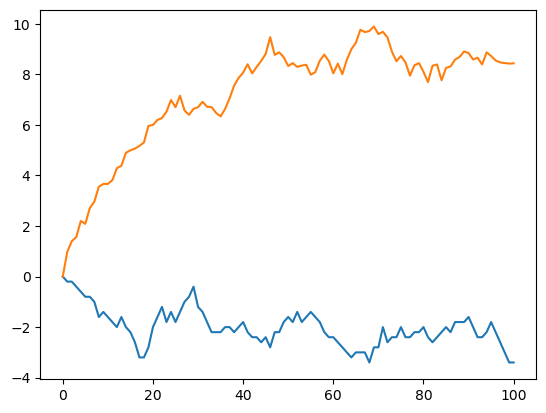

In [40]:
np.random.seed(0)
def random_walk(n, N):
    vec_prob = [1/2, 1/2]
    a = [-1, 1]
    steps = np.random.choice(a=a, size = (N,n), p=vec_prob)
    walks = np.zeros((N,n+1))
    walks[:,1:] = np.cumsum(steps, axis = 1)

    return walks.mean(axis=0), walks.std(axis=0)

medie, dev = random_walk(100, 10)
x=[i for i in range(101)]

plt.plot(x, medie)
plt.plot(x, dev)


## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [60]:
np.random.seed(42)
a = np.random.normal(0,1, size=(5,9))


a_abs = np.abs(a-0.1)

j = np.argmin(a_abs, axis=1)
i = np.arange(a.shape[0])

a[i,j]


array([-0.1382643 ,  0.24196227,  0.11092259, -0.01349722,  0.17136828])

## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


In [63]:
import pandas as pd

data = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
data.Fare.nlargest(10)

258    512.3292
679    512.3292
737    512.3292
27     263.0000
88     263.0000
341    263.0000
438    263.0000
311    262.3750
742    262.3750
118    247.5208
Name: Fare, dtype: float64

In [66]:
print(data.Fare.mean())
print(data.SibSp.mean())
print(data.Age.mean())

32.204207968574636
0.5230078563411896
29.69911764705882


In [68]:
data['Family_index']=(data.SibSp+data.Parch)/data.Fare
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.137931
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.014029


In [72]:
data.Name[data.Family_index.idxmax()]

'Andersson, Miss. Erna Alexandra'

In [74]:
data[data.Fare>100].head(2) #altrimenti sono troppi

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,0.019011
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C,0.006825


In [76]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'top 10 passeggeri che hanno pagato di più')

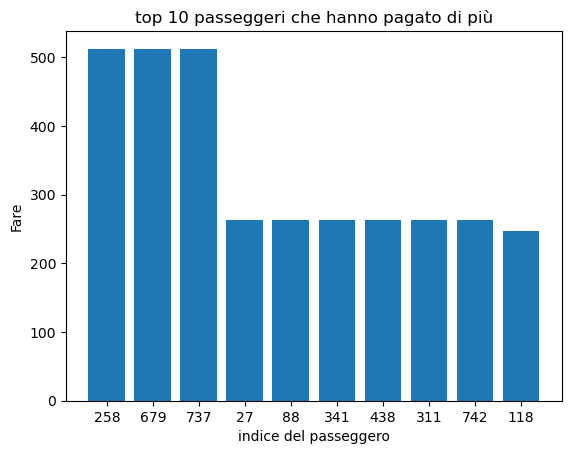

In [88]:
passeggeri = data.Fare.nlargest(10).index
passeggeri= [str(passenger) for passenger in passeggeri]
tariffe = data.Fare.nlargest(10).values

plt.bar(passeggeri, tariffe)
plt.xlabel('indice del passeggero')
plt.ylabel('Fare')
plt.title('top 10 passeggeri che hanno pagato di più')

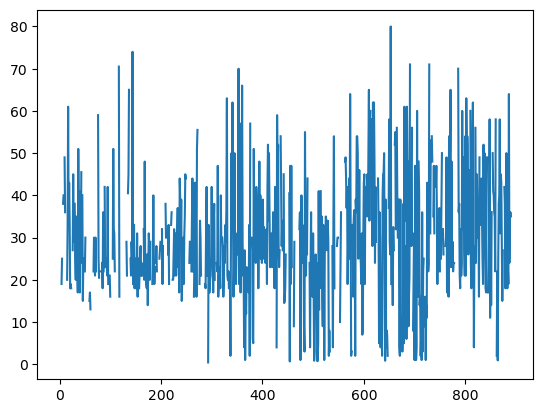

In [93]:
data_sorted = data.sort_values(by='Fare', ascending=True)
x = [i for i in range(len(data))]

plt.plot(x, data_sorted.Age)


## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


In [94]:
import seaborn as sns

In [100]:
data = sns.load_dataset("penguins")
print(data.info()) #ci sono 344 osservazioni e 7 varibili

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB
None


In [99]:
print(data.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [114]:
data.sex.unique() #trovo i livelli

n_maschi = data[data.sex=='Male'].count()
n_femmine = data[data.sex=='Female'].count()

n_maschi>n_femmine #Male è l'occorenza maggiore

data.sex = data.sex.fillna('Male')
data.sex.isna() #controllo di aver tolto gli na

0      False
1      False
2      False
3      False
4      False
       ...  
339    False
340    False
341    False
342    False
343    False
Name: sex, Length: 344, dtype: bool

In [115]:
data.body_mass_g = data.body_mass_g.dropna()

In [117]:
print(data.duplicated().sum()) 

0


In [120]:
print(data.groupby('species')['body_mass_g'].mean())

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


<Axes: xlabel='species', ylabel='body_mass_g'>

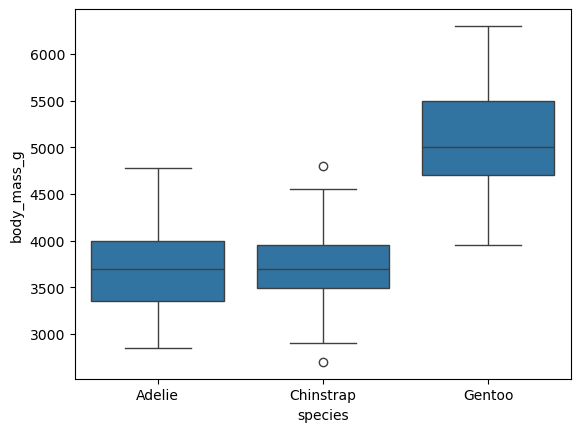

In [121]:
sns.boxplot(data=data, x='species', y='body_mass_g')

<Axes: xlabel='species', ylabel='body_mass_g'>

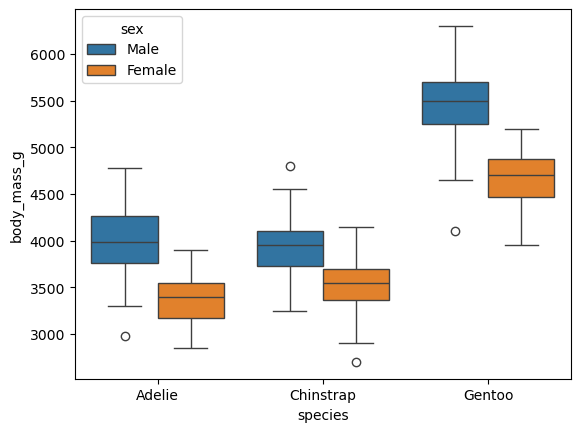

In [122]:
sns.boxplot(data=data, x='species', y='body_mass_g', hue='sex')

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


In [123]:
import scipy as sp

In [132]:
x = np.linspace(0,10,100)
y = 3 * x +2 + np.random.normal(0,1,100)



def fit_line(x, y):
    def lineare(x, m, q):
        return m*x + q
    popt, _ = sp.optimize.curve_fit(lineare, x, y)
    m = popt[0]
    q = popt[1]
    stringa = 'y = {} * x + {}'.format(m,q)
    return m, q, stringa

In [135]:
a, b, s = fit_line(x,y)

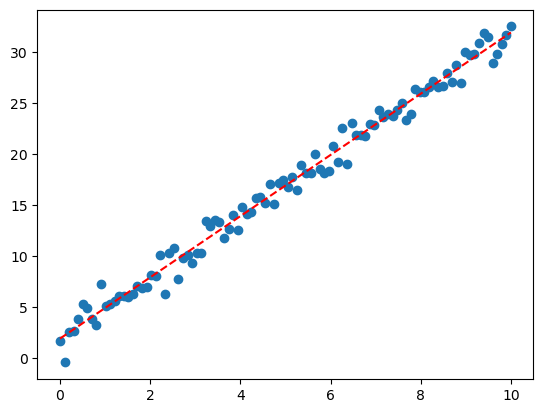

In [138]:
plt.scatter(x,y)
plt.plot(x, lineare(x, a, b), color='r', linestyle='--')